In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

plt.style.use("seaborn-v0_8")
sns.set_palette("viridis")

In [2]:
# Load Dataset

df = pd.read_excel("../data/Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Dataset Shape

df.shape

(541909, 8)

In [4]:
# Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [5]:
# Check Missing Values

df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
# Remove Missing CustomerID

df = df.dropna(subset=["CustomerID"])

In [7]:
# Remove Cancelled Orders

df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [8]:
# Remove Negative Quantity

df = df[df["Quantity"] > 0]

In [9]:
# Remove Negative Price

df = df[df["UnitPrice"] > 0]

In [10]:
# Convert InvoiceDate to Datetime

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [11]:
# Create Total Revenue Column

df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [12]:
# Total Revenue

df["TotalPrice"].sum()

np.float64(8911407.904)

In [13]:
# Unique Customers

df["CustomerID"].nunique()

4338

In [14]:
# Unique Transactions

df["InvoiceNo"].nunique()

18532

In [15]:
# Create Monthly Column

df["Month"] = df["InvoiceDate"].dt.to_period("M")

In [16]:
# Monthly Revenue

monthly_sales = df.groupby("Month")["TotalPrice"].sum()
monthly_sales.head()

Month
2010-12    572713.890
2011-01    569445.040
2011-02    447137.350
2011-03    595500.760
2011-04    469200.361
Freq: M, Name: TotalPrice, dtype: float64

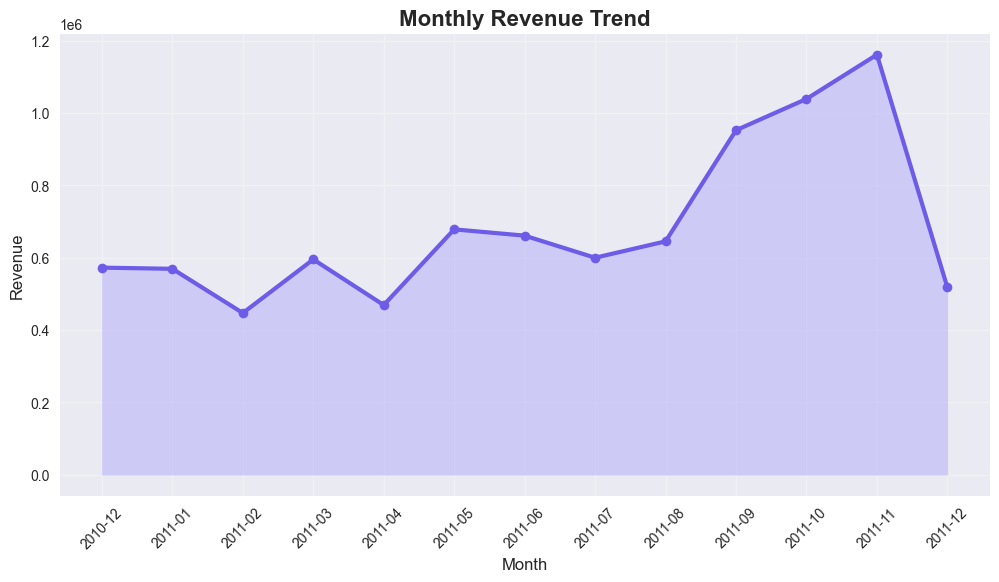

In [36]:
# Monthly Revenue Visualization

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    color="#6C5CE7",
    marker="o",
    linewidth=3
)

plt.fill_between(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    color="#A29BFE",
    alpha=0.4
)

plt.title("Monthly Revenue Trend", fontsize=16, fontweight="bold")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Revenue", fontsize=12)

plt.xticks(rotation=45)

plt.grid(alpha=0.3)
plt.savefig("../visuals/monthly_revenue.png", dpi=300, bbox_inches="tight")


plt.show()

In [18]:
# Top Countries by Revenue

country_sales = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10)
country_sales

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: TotalPrice, dtype: float64

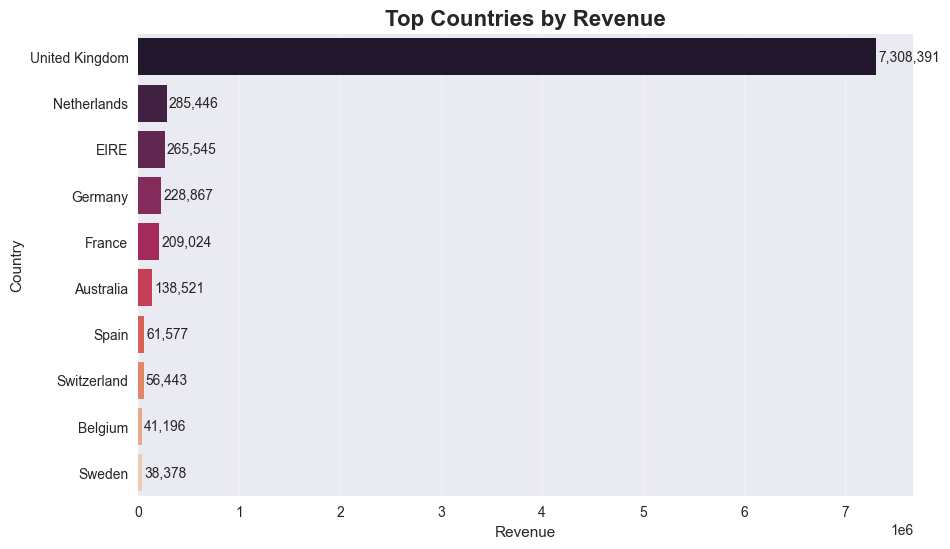

In [37]:
# Visualization of Top Countries

plt.figure(figsize=(10,6))

colors = sns.color_palette("rocket", len(country_sales))

ax = sns.barplot(
    x=country_sales.values,
    y=country_sales.index,
    hue=country_sales.index,
    palette=colors,
    legend=False
)

plt.title("Top Countries by Revenue", fontsize=16, fontweight="bold")
plt.xlabel("Revenue")
plt.ylabel("Country")

# Add value labels
for i, v in enumerate(country_sales.values):
    ax.text(v + 20000, i, f"{int(v):,}", va="center")

plt.grid(axis="x", alpha=0.3)
plt.savefig("../visuals/top_countries.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
# Create Snapshot Date

snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [21]:
# Create RFM Table

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [22]:
# Remove Extreme Monetary Outliers

rfm = rfm[rfm["Monetary"] < rfm["Monetary"].quantile(0.99)]

rfm.describe()

,Recency,Frequency,Monetary
count,4294.000000,4294.000000,4294.000000
mean,93.230554,3.868188,1411.238783
std,100.084948,4.900059,2108.837909
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,305.867500
50%,51.000000,2.000000,663.730000
75%,143.000000,4.750000,1612.415000
max,374.000000,93.000000,19824.050000


In [23]:
# Rename RFM Columns

rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40
12352.0,36,8,2506.04


In [24]:
# Scale RFM Data

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [25]:
# Elbow Method for Optimal Clusters

inertia = []

for k in range(2,10):
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    
    kmeans.fit(rfm_scaled)
    
    inertia.append(kmeans.inertia_)

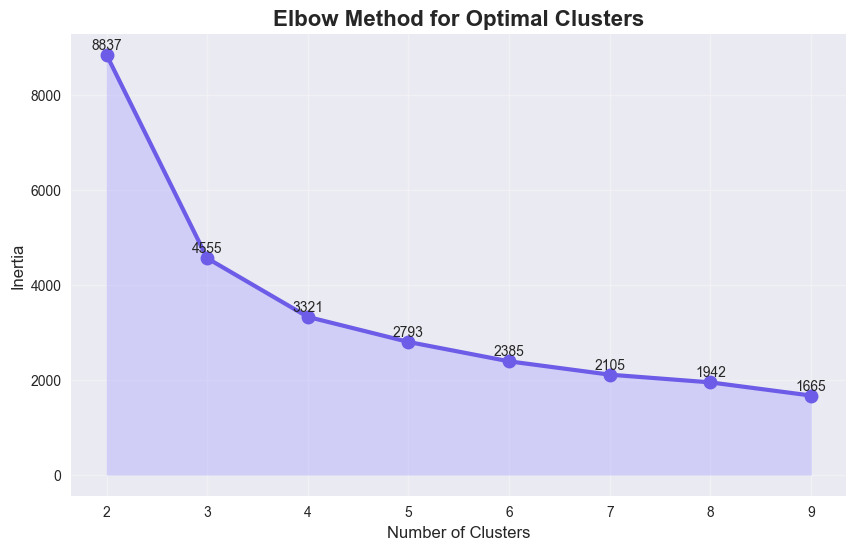

In [38]:
# Plot Elbow Method

plt.figure(figsize=(10,6))

plt.plot(
    range(2,10),
    inertia,
    marker="o",
    linewidth=3,
    markersize=10,
    color="#6C5CE7"
)

plt.fill_between(
    range(2,10),
    inertia,
    color="#A29BFE",
    alpha=0.35
)

plt.title("Elbow Method for Optimal Clusters", fontsize=16, fontweight="bold")
plt.xlabel("Number of Clusters", fontsize=12)
plt.ylabel("Inertia", fontsize=12)

plt.xticks(range(2,10))
plt.grid(alpha=0.3)

# Add value labels
for x, y in zip(range(2,10), inertia):
    plt.text(x, y + 120, f"{int(y)}", ha="center", fontsize=10)
plt.savefig("../visuals/elbow_method.png", dpi=300, bbox_inches="tight")

plt.show()

### Cluster Selection

The elbow plot suggests that the reduction in inertia begins to slow after k=4, indicating diminishing returns from adding more clusters. Therefore, 4 clusters were selected as a practical and interpretable segmentation choice for business analysis. This choice is heuristic rather than strictly optimized, but it provides balanced and meaningful customer groups for downstream interpretation.

In [27]:
# Apply K-Means Clustering

kmeans = KMeans(n_clusters=4, random_state=42)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12347.0,2,7,4310.00,2
12348.0,75,4,1797.24,3
12349.0,19,1,1757.55,3
12350.0,310,1,334.40,0
12352.0,36,8,2506.04,2


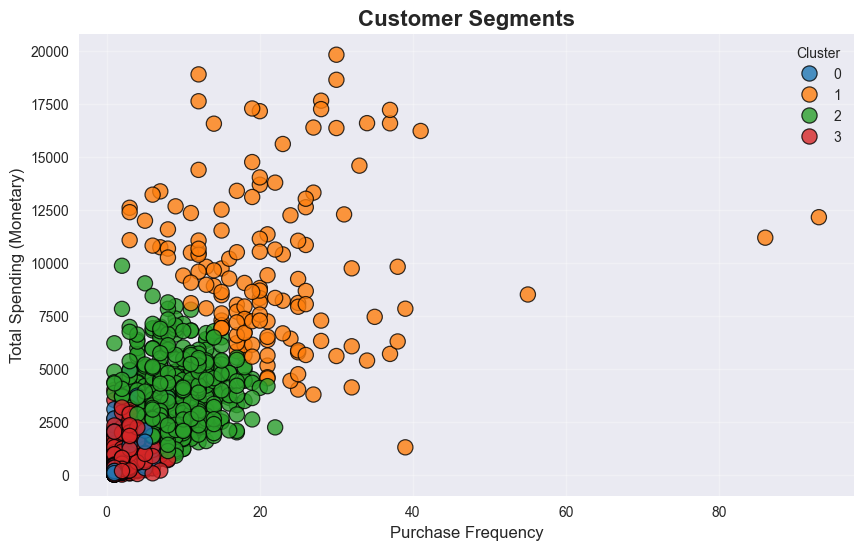

In [39]:
# Customer Segments Visualization

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=rfm["Frequency"],
    y=rfm["Monetary"],
    hue=rfm["Cluster"],
    palette="tab10",
    s=120,
    alpha=0.8,
    edgecolor="black"
)

plt.title("Customer Segments", fontsize=16, fontweight="bold")
plt.xlabel("Purchase Frequency", fontsize=12)
plt.ylabel("Total Spending (Monetary)", fontsize=12)

plt.grid(alpha=0.3)

plt.legend(title="Cluster", fontsize=10)
plt.savefig("../visuals/customer_segments.png", dpi=300, bbox_inches="tight")
plt.show()

In [29]:
# Cluster Summary

rfm.groupby("Cluster").agg({
    "Recency":"mean",
    "Frequency":"mean",
    "Monetary":["mean","count"]
})

Recency  Frequency     Monetary      
               mean       mean         mean count
Cluster                                          
0        251.963832   1.484848   434.131624  1023
1         14.971631  21.453901  9815.219574   141
2         27.333333   8.431373  3330.253683   714
3         50.060430   2.502483   767.382282  2416

In [30]:
# Prepare Data for CLV Prediction

X = rfm[["Recency","Frequency"]]

y = rfm["Monetary"]

In [31]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [32]:
# Train Random Forest Model

model = RandomForestRegressor()

model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [33]:
# Predict Customer Spend
pred = model.predict(X_test)

In [34]:
# Model Performance

print("R2 Score:", r2_score(y_test,pred))

R2 Score: 0.45631274397160904


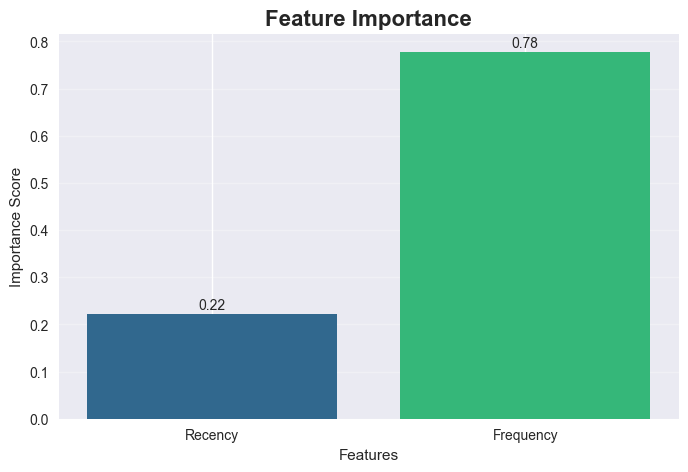

In [40]:
# Feature Importance

importance = model.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))

colors = sns.color_palette("viridis", len(features))

bars = plt.bar(features, importance, color=colors)

plt.title("Feature Importance", fontsize=16, fontweight="bold")
plt.xlabel("Features")
plt.ylabel("Importance Score")

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.2f}",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)
plt.savefig("../visuals/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()